---
title: Taking Derivatives with Automatic Differentiation
author: Mark Fuge
date: 'October 1 2025'
format:
    html:
        code-fold: false
---

Taking derivatives with respect to functions or parameters is one of the most common and fundamental operations that we will need for Machine Learning (and in fact for Scientific Computing, in general). Throughout your life so far, you have probably learned about three main ways to compute derivatives:

1. **Analytical Differentiation**: computing the analytical derivative manually using the rules of calculus and pencil and paper. The benefit of this approach is that it is exact, but the drawback is that it can be tedious, manual, and error-prone for complex functions. Once completed, we get a function that has the exact derivative everywhere.
2. **Symbolic Differentiation**: using a computer algebra system (CAS) to compute the analytical derivative symbolically. The main benefit of this approach is that it is exact and can handle more complex functions than manual differentiation, but the drawback is that it can be slow and may produce very complicated expressions that are difficult to evaluate numerically (a phenomenon known as *expression swell*). This method also produces a function that has the exact derivative everywhere as a single (often very large) function.
3. **Numerical Differentiation**: using finite difference approximations to compute the derivative numerically, for example using the formula $\frac{df}{dx} \approx \frac{f(x+h) - f(x)}{h}$ for some small $h$. The main benefit of this approach is that it is easy to implement and can handle any function that can be evaluated numerically, but its drawbacks are that it only approximates the derivative, can be sensitive to the choice of $h$, suffers from numerical precision issues, and only provides the derivative at a single evaluated point (unlike analytical or symbolic approaches that produce a function of the derivative that is valid everywhere).

This chapter won't cover those approaches in detail, as its main goal is to introduce you to a fourth way to compute derivatives called *Automatic Differentiation* (AD). This approach inherits some of the benefits of analytical and symbolic differentiation, in that it computes *exact* derivatives (unlike numerical differentiation). It's main drawback is that the effort used to compute the derivatives will be only useful for a single evaluation point (similar to numerical differentiation). Unlike symbolic differentiation, AD is very efficient and does not suffer from expression swell, although it does require extra bookkeeping to keep track of intermediate values and derivatives (as we will see), which can add some memory and computational overhead.

| Method                     | Benefits                                                                 | Drawbacks                                                                 |
|----------------------------|--------------------------------------------------------------------------|---------------------------------------------------------------------------|
| Analytical Differentiation  | Exact derivatives, valid everywhere                                    | Tedious, manual, error-prone for complex functions                       |
| Symbolic Differentiation    | Exact derivatives, can handle complex functions                         | Slow, may produce complicated expressions (expression swell)            |
| Numerical Differentiation   | Easy to implement, handles any numerically evaluable function          | Only approximates derivative, sensitive to $h$, precision issues, pointwise |
| Automatic Differentiation   | Exact derivatives, efficient computation                               | More complex implementation, potential overhead                        |

: Overview of different methods for computing derivatives.

With this overview in mind, we can now introduce Automatic Differentiation using a simple example, and then later demonstrate how to use it via some practical examples.

**Learning Objectives**

By the end of this chapter, you should be able to:

1. Build a computational graph and perform forward-mode automatic differentiation by hand.
2. Perform reverse-mode automatic differentiation (backpropagation) by hand and explain when forward or reverse mode is cheaper.
3. Use `torch.autograd`, compare it with finite differences, and recognize when either should not be trusted.
4. Use gradients in an optimizer (Adam, L-BFGS) and interpret the optimization path.
5. Differentiate through a numerical simulator to obtain sensitivities and fit physical parameters, and recognize when such gradients vanish, explode, or mislead.

## Automatic Differentiation

To demonstrate how Automatic Differentiation works, let's take a simple example function, for which we can easily compute the derivatives manually/analytically, so that we can check out results. Let's consider the function: 

$$
f(x_1, x_2) = \ln(x_1) + x_1 \cdot x_2 - \sin(x_2)
$$  

evaluated at $x_1 = 2, x_2 = 5$.

Analytically, this function is simple enough that we could actually compute the partial derivatives manually:
$$\frac{\partial f}{\partial x_1} = \frac{1}{x_1} + x_2 = 0.5 + 5 = 5.5$$

$$\frac{\partial f}{\partial x_2} = x_1 - \cos(x_2) = 2 - 0.284 = 1.716$$

However, for the sake of this example, we will use Automatic Differentiation to compute these derivatives instead. The first step of Automatic Differentiation is to build up a *Computational Graph* of the function using a library of easy to compute derivatives (e.g., $\frac{\partial}{\partial x} x^n \rightarrow n\cdot x^{n-1}$)

### Build the Computational Graph

To build the computational graph, we break the function down into its elementary operations step by step, starting from the beginning (i.e., the inputs to the function). We will introduce intermediate variables ($V_\#$) to represent the outputs of these intermediate operations. Let's define:


<!-- Figure source: figures/computational_graph.mmd; rendered to PNG with tools/render_mermaid.md (no live mermaid blocks in the book). -->
![The computational graph of $f(x_1, x_2)$.](figures/computational_graph.png){width=80%}

Now with the graph in place, we can compute the first stage of Automatic Differentiation, which is the *forward pass* through the function.

### Compute the Forward Pass

The Forward Pass is simply evaluating the function at the given input values, but we will do this step by step, following the computational graph we just built. It will be useful to keep track of the intermediate values in a table for reference later. (In reality, the computer will do this for us, but we are doing it by hand here to illustrate the process.)

| Node | Definition                | Value                         |
|------|----------------------------|-------------------------------|
| $V0$   | $x_1$                    | 2                             |
| $V1$   | $x_2$                    | 5                             |
| $V2$   | $\ln(V0)$                | $\ln(2) \approx 0.6931$     |
| $V3$   | $V0 \cdot V1$            | $2 \cdot 5 = 10$            |
| $V4$   | $-\sin(V1)$              | $-\sin(5) \approx 0.9589$   |
| $V5$   | $V2 + V3$                | $0.6931 + 10 = 10.6931$     |
| $V6$   | $V5 + V4$                | $10.6931 + 0.9589 \approx 11.6520$ |

If we pass in our initial points (x1, x2) through this forward pass, we can look at the final node (V6) to get the answer: 
$$
f(2, 5) \approx 11.6520
$$

Great, this matches what we would expect. At this point, we have just evaluated the function forward, and we don't yet have any derivatives. From here, things get interesting and bifurcate into two main types of Automatic Differentiation: Forward Mode AD and Backward Mode AD. Each of these has important but different uses for reasons that will become clear as we work through the example. Let's start with Forward Mode AD. In both cases, we will start with the initial work we already did with the forward pass above.

### Computing Forward Mode AD (tangent propagation)

Forward Mode AD allows us to compute *directional derivatives* of the function, as well as that same directional derivative at *any intermediate node* in the computational graph. This is useful for computing derivatives of functions that have a small number of inputs (e.g., 1-10), but potentially a large number of outputs that we might be interested in. For example, if we were computing a trajectory of a dynamical system, we might want to know how the final state of the system changes with respect to some initial condition. In this case, the initial condition is the input, and the final state is the output. There might be many intermediate states along the way that we also want to know how they change with respect to the initial condition, such as the state or total energy at each time step. Forward Mode AD allows us to compute all of these derivatives in only a single pass through the computational graph.

To see how this works, we will introduce a new variable $\dot{V}$ to represent the derivative of each node with respect to some input direction. We will use the notation $\dot{V} = \frac{dV}{dx}$, where $x$ is some input variable.

**Case A: derivative wrt $x_1$ ($\dot{x}_1 = 1, \dot{x}_2 = 0$)**

| Node | Definition                        | Value                         |
|------|-----------------------------|-------------------------------|
| $\dot{V_0}$   | $\dot{x_1}$                 | 1                             |
| $\dot{V_1}$   | $\dot{x_2}$                 | 0                             |
| $\dot{V_2}$   | $d(\ln V_0)/dV_0 = 1/V_0 \dot{V_0}$   | $(1/2)\cdot 1 = 0.5$        |
| $\dot{V_3}$   | $d(V_0 \cdot V_1)/dV_0 = \dot{V_0} V_1 + V_0 \dot{V_1}$  | $5\cdot1+2\cdot0=5$ |
| $\dot{V_4}$   | $-\cos(V_1)\dot{V_1}$      | $-\cos(5)\cdot 0 = 0$       |
| $\dot{V_5}$   | $\dot{V_3} + \dot{V_2}$    | $0.5 + 5 = 5.5$             |
| $\dot{V_6}$   | $\dot{V_5} + \dot{V_4}$    | $5.5 + 0 = 5.5$             |

$$
\frac{\partial f}{\partial x_1} = 5.5
$$



**Case B: derivative wrt $x_2$ ($\dot{x}_1 = 0, \dot{x}_2 = 1$)**

**Exercise:** Fill in a similar table as above to compute the derivative of the function with respect to $x_2$ using Forward Mode AD.

You can check your answer using the known analytical derivative of the function that you can compute by hand:
$$
\frac{\partial f}{\partial x_2} \approx 1.7163
$$

OK, great, we see that with some bookkeeping, we have correctly computed the derivatives of the function with respect to each input variable. Note that we had to do two passes through the computational graph to get both derivatives, since they were different directional derivatives. If we had a third input variable, we would need a third pass, and so on. This is why Forward Mode AD is best suited for functions with a small number of inputs.

On the flip side, if we were interested in the derivative of some intermediate node in the computational graph with respect to an input variable, we would have that information available as well. For example, if we wanted to know how $V3$ changes with respect to $x_1$, we can see from the table above that $\frac{\partial V3}{\partial x_1} = 5$. We got this in the process of computing the final function, so this derivative comes "along for the ride" without additional cost on our part. This is a powerful feature of Forward Mode AD that we will see is not available in Backward Mode AD: we can get a specific directional derivatives of any intermediate node from the computational graph via the same Forward Mode pass, but the cost of this scales with the number of input variables or number of directional derivatives we want to compute.




### Computing Reverse Mode AD (backpropagation)

While Forward Mode AD efficiently found directional derivatives, if we wanted to compute the full gradient of the output with respect to all of the input variables, we would need to do a separate pass for each input variable. This means that the cost of computing the full gradient scales with the number of input variables. If we have a function with a large number of input variables (e.g., 1000s or more), this can be very expensive. To address this, we can use Reverse Mode AD, which will allow us to compute the full gradient of every input variable to a function using a single "backward pass" through the computational graph. This is particularly useful for functions that have a small number of outputs (e.g., 1-10), but a very large number of inputs, such as a Neural Network in Machine Learning or mesh coordinates in a Finite Element or Computational Fluid Dynamics simulation.

To see how this works, we will introduce a new variable $\bar{V}$ to represent the *adjoint* of each node with respect to the output. We will use the notation $\bar{V} = \frac{\partial f}{\partial V}$, where $f$ is the final output of the function. The adjoint represents how much a small change in that intermediate node would affect the final output of the function.

Similarly to Forward Mode AD, we will have to pick a specific output that we wish to compute the gradient with respect to. In this case, since we are computing the gradient of the output with respect to all input variables, we can set the final output node with a value of 1, i.e., $\bar{V6} = 1$. From there, we will propagate each adjoint backward through the computational graph using the chain rule.





| Node | Equation for the adjoint        | Value                         |
|------|-----------------------------|-------------------------------|
| $\bar{V_6}$   | $\frac{\partial f}{\partial V_6}$ | 1                             |
| $\bar{V_5}$   | $\frac{\partial f}{\partial V_6} \frac{\partial V_6}{\partial V_5} = \bar{V_6}1$ | 1                             |
| $\bar{V_4}$   | $\frac{\partial f}{\partial V_6} \frac{\partial V_6}{\partial V_4} = \bar{V_6}1$ | 1                             |
| $\bar{V_3}$   | $\frac{\partial f}{\partial V_5} \frac{\partial V_5}{\partial V_3} = \bar{V_5}1$ | 1                             |
| $\bar{V_2}$   | $\frac{\partial f}{\partial V_5} \frac{\partial V_5}{\partial V_2} = \bar{V_5}1$ | 1                             |
| $\bar{V_1}$   | from V3: $\bar{V_3}\cdot V_1=2$ <br> + from V4: $-\cos(5)\cdot \bar{V_4} \approx -0.2837$ | 1.7163 |
| $\bar{V_0}$   | from V2: $\bar{V_2}(1/V_0)\cdot1=0.5$ <br> + from V3: $\bar{V_3}\cdot V_1=5$ | 5.5 |

We can now verify the final gradients, which match our analytical solution:

$$
\nabla f(2,5) = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2} \right) = (5.5, \, 1.7163)
$$


However, unlike Forward Mode AD, we see that we now have access not only to the gradients of the input variables, but also to the gradients of **all intermediate nodes** in the computational graph, and we received all of them via the same amount of work/computation!




## PyTorch Autograd Example with Simple Function
Ok let's use automatic differentiation to compute a simple derivative of our earlier analytical function:

$$y = f(x_0,x_1) = \ln(x_0) + x_0 \cdot x_1 - \sin(x_1)$$

And as with before, we'll evaluate the derivative of this function at $$x_0 = 2, x_1=5$$

We can analytically compute the derivative and code it up so that we can verify accuracy later:

In [1]:
#| code-fold: false
import numpy as np
def true_grad(x0,x1):
    return np.array([
        1/x0 + x1,
        x0 - np.cos(x1)
    ])
true_grad(2,5)

array([5.5       , 1.71633781])

But now let's see how to use [PyTorch](https://pytorch.org/ ) to get this using Automatic Differentiation:

### Automatic Differentiation using PyTorch

In [2]:
import torch
x = torch.tensor([2.0, 5.0], requires_grad=True)
print(x)

tensor([2., 5.], requires_grad=True)


In [3]:
def f(x):
    return torch.log(x[0]) + x[0]*x[1] - torch.sin(x[1])
y = f(x)
print(y)

tensor(11.6521, grad_fn=<SubBackward0>)


In [4]:
x.grad

In [5]:
# Now call the backward AD pass so that we can compute gradients
y.backward()
# Now we can ask for the gradient:
x.grad

tensor([5.5000, 1.7163])

Let's see how well it approximated the true gradient:

In [6]:
true_grad(2,5) - x.grad.numpy()

array([0.00000000e+00, 1.45108339e-08])

### Finite Differences using SciPy

Now let's compare this to computing the same gradient, but using Numerical Differentiation. SciPy's `approx_fprime` uses the one-sided (forward) difference formula from the introduction, $\frac{f(x + \epsilon) - f(x)}{\epsilon}$, one coordinate at a time:

In [7]:
from scipy import optimize
x_np = np.array([2.0, 5.0])
def f_np(x):
    return np.log(x[0]) + x[0]*x[1] - np.sin(x[1])
#y_np = f_np(x_np)
# This computes finite differences opf f_np at x_np:
optimize.approx_fprime(x_np, f_np, epsilon=1e-4)

array([5.4999875 , 1.71628987])

Let's see how well it approximated the true gradient:

In [8]:
true_grad(2,5) - optimize.approx_fprime(x_np, f_np, epsilon=1e-4)

array([1.24995903e-05, 4.79457300e-05])

In [9]:
def numerical_error(e):
    return true_grad(2,5) - optimize.approx_fprime(x_np, f_np, epsilon=e)
#error = lambda e: true_grad(2,5) - optimize.approx_fprime(x_np, y_np, epsilon=e)
epsilons = np.logspace(-13,1,num=21)
errors = [np.linalg.norm(numerical_error(e)) for e in epsilons]

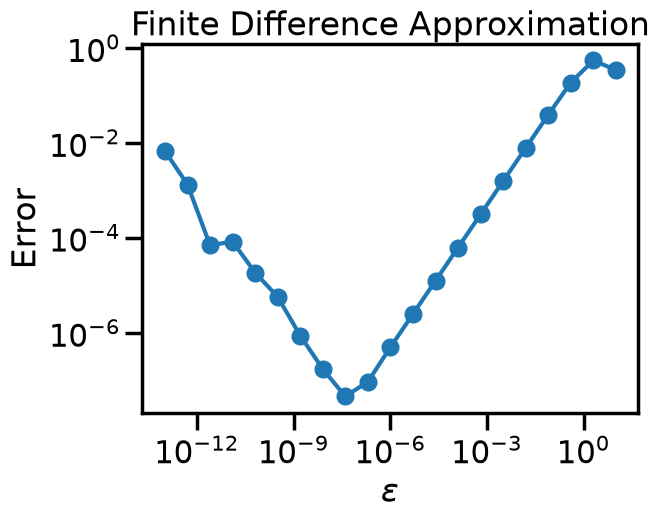

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('poster')
np.random.seed(1)

plt.figure()
plt.loglog(epsilons,errors,marker='o')
plt.xlabel('$\epsilon$')
plt.ylabel('Error')
plt.title('Finite Difference Approximation')
plt.show()

## PyTorch Autograd Example with Optimization

This example shows how to use AD and PyTorch to perform gradient based optimization on a simple test function

In [11]:
# Example of the McCormick Function
def mccormick(x):
    return torch.sin(x[0]+x[1]) + (x[0]-x[1])**2 - 1.5*x[0]+2.5*x[1]+1
f = mccormick

x = torch.tensor([-4.0, 4.0], requires_grad=True)
y = f(x)

What does this function look like?

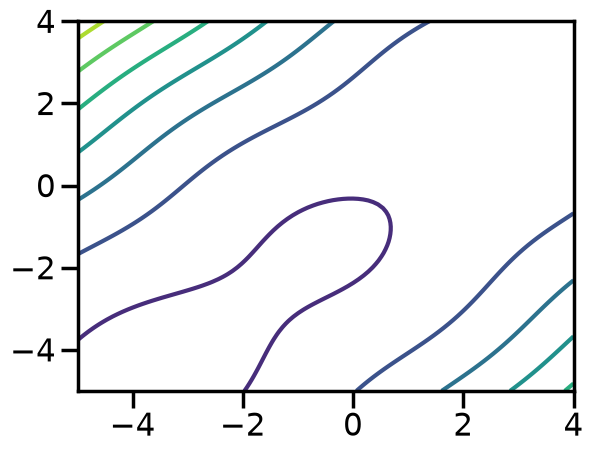

In [12]:
X_plot = torch.meshgrid(torch.linspace(-5,4,100),torch.linspace(-5,4,100), indexing='ij')
x_plot,y_plot = X_plot
plt.figure()
plt.contour(x_plot,y_plot,f(X_plot))
plt.show()

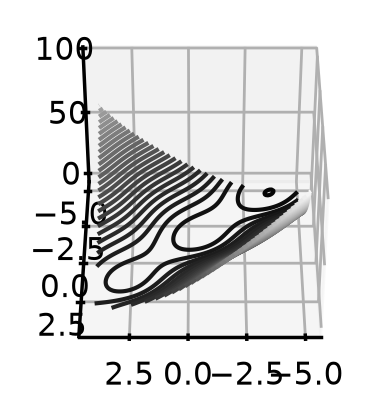

In [13]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(x_plot, y_plot, f(X_plot), 50, cmap='binary_r')
ax.view_init(40, 90)
plt.show()

Now let's say I want to optimize this. I could compute the analytical derivative. Or, I could compute the backward-mode AD on the inputs:

In [14]:
# Pick a starting point:
x = torch.tensor([-4.0, 4.0], requires_grad=True)
# Evaluate y
y = f(x)
# Now call the backward AD pass so that we can compute gradients
y.backward()
# Now we can get the gradient
x.grad

tensor([-16.5000,  19.5000])

### Using Automatic Differentiation for Optimization

Automatic Differentiation can now gives us an gradient, which a gradient-based optimizer can then use to perform gradient descent, as we covered in a previous chapter, where the main difference is now we do not have to compute the gradients manually. Recall from our introduction to gradient descent that $w_{t+1} = w_t - \alpha\, \nabla J(w_t)$, and that we had covered the use of momentum to accelerate and stablize vanilla SGD. As a reminder, the gradient descent with momentum step looked like the following:

$$
\begin{aligned}
v_{t+1} &= \beta\, v_t + \nabla_w J(w_t) \\
w_{t+1} &= w_t - \alpha\, v_{t+1}
\end{aligned}
$$

We saw with normalization that having different dimensions or curvatures in the loss landscape could induce slow convergence behavior (even with momentum), and so more advanced versions of GD are used in practice, with one of the most widely used variants being the Adam Optimizer (@kingma2015adam), which we'll state below and then define how this differs from regular momentum. Importantly, the original Adam paper defined the momentum term with a different symbol ($m_t$ instead of $v_t$ which we used above, and re-purposes the symbol $v_t$ to scale coordiante dimensions):

$$
\begin{aligned}
m_t &= \beta_1\, m_{t-1} + (1 - \beta_1)\, \nabla_w J(w_t), \qquad v_t = \beta_2\, v_{t-1} + (1 - \beta_2)\, \nabla_w J(w_t)^2, \\
w_{t+1} &= w_t - \alpha\, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}, \qquad \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}.
\end{aligned}
$$

The square, the square root and the division are taken coordinate by coordinate, and the hats correct for both averages starting at zero. PyTorch's defaults are $\beta_1 = 0.9$, $\beta_2 = 0.999$ and $\epsilon = 10^{-8}$. The average $\hat{m}_t$ plays the role of momentum. Dividing it by $\sqrt{\hat{v}_t}$, the typical size of recent gradients, removes the scale of the gradient. If the gradient has kept the same sign for a while, the ratio is close to $\pm 1$ and the coordinate moves by about $\alpha$, whether the slope is steep or shallow. (On the first step the ratio is exactly $\pm 1$.) The step gets shorter when the gradient changes sign, so that positive and negative values cancel in $\hat{m}_t$, or when the gradient becomes small compared with the earlier gradients that $\hat{v}_t$ still remembers ($\beta_2$ is close to 1, so it remembers them for a long time). This is the main difference from gradient descent: in Adam the learning rate sets the length of the step in each coordinate, and the size of the gradient does not. **AdamW**, which we use below, is Adam with *weight decay*: each step also multiplies $w$ by $1 - \alpha\lambda$, which pulls it toward zero (PyTorch's default is $\lambda = 0.01$). You can think of this as just adding an additional L2 penalty to $w$.

Let's run AdamW on the McCormick function from the starting point $(-4, 4)$:

In [15]:
# Take an initial guess at the optimum:
x = torch.tensor([-4.0, 4.0], requires_grad=True)
# The minimum in the plotted window is at about x_opt = [-0.547, -1.547] (the star in the L-BFGS plot below)
# Initialize the optimizer
optimizer = torch.optim.AdamW([x], lr=1)
num_steps = 50
steps = [np.array(x.detach().numpy())]
# Take num_steps steps
for i in range(num_steps):
    optimizer.zero_grad()
    y = f(x)
    y.backward()
    optimizer.step()
    with torch.no_grad():
        steps.append(np.array(x.detach().numpy()))
        print(x)
steps = np.array(steps)

tensor([-2.9600,  2.9600], requires_grad=True)
tensor([-1.9481,  1.9436], requires_grad=True)
tensor([-0.9857,  0.9653], requires_grad=True)
tensor([-0.1051,  0.0453], requires_grad=True)
tensor([ 0.6508, -0.7906], requires_grad=True)
tensor([ 1.2368, -1.5138], requires_grad=True)
tensor([ 1.6219, -2.0992], requires_grad=True)
tensor([ 1.8020, -2.5325], requires_grad=True)
tensor([ 1.7979, -2.8129], requires_grad=True)
tensor([ 1.6423, -2.9514], requires_grad=True)
tensor([ 1.3704, -2.9664], requires_grad=True)
tensor([ 1.0147, -2.8804], requires_grad=True)
tensor([ 0.6043, -2.7165], requires_grad=True)
tensor([ 0.1659, -2.4983], requires_grad=True)
tensor([-0.2759, -2.2482], requires_grad=True)
tensor([-0.6981, -1.9879], requires_grad=True)
tensor([-1.0796, -1.7375], requires_grad=True)
tensor([-1.4026, -1.5143], requires_grad=True)
tensor([-1.6534, -1.3326], requires_grad=True)
tensor([-1.8238, -1.2020], requires_grad=True)
tensor([-1.9113, -1.1271], requires_grad=True)
tensor([-1.91

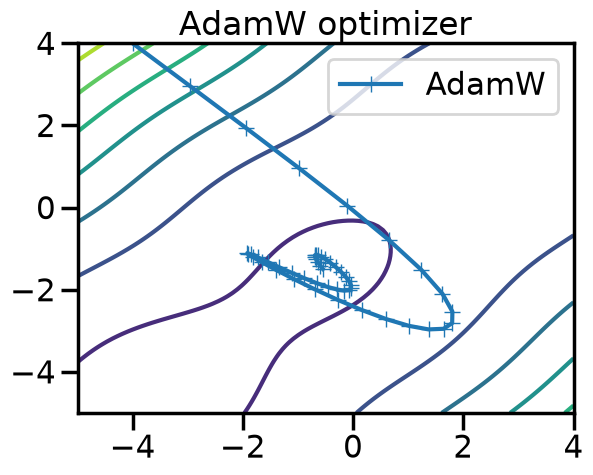

In [16]:
plt.figure()
plt.contour(x_plot,y_plot,f(X_plot))
plt.plot(steps[:,0],steps[:,1],marker='+',label = "AdamW")
plt.legend()
plt.title("AdamW optimizer")
plt.show()

### L-BFGS

Newton's method steps to the minimum of a local quadratic model of the function, $w_{t+1} = x_t - H^{-1} g_t$, where $H$ is the matrix of second derivatives (the Hessian). L-BFGS (limited-memory Broyden-Fletcher-Goldfarb-Shanno) is a *quasi-Newton* method. It never forms $H$. Instead it approximates $H^{-1} g_t$ from the changes in position and gradient over the last few iterations. Like Adam it needs only gradients, but it uses them to estimate the curvature of the function. Where the function is close to a quadratic, the L-BFGS direction points almost straight at the minimum.

Two details of `torch.optim.LBFGS` matter for reading the plot below. One call of `optimizer.step(closure)` runs up to `max_iter=20` L-BFGS iterations and calls `closure` once per iteration, so the 5 plotted steps contain up to 100 iterations. And unless you pass `line_search_fn="strong_wolfe"`, each iteration moves a fixed fraction `lr` of the quasi-Newton step. With `lr=0.05` that is 5% of the way to the minimum of the current quadratic model.

In [17]:
# Take an initial guess at the optimum:
x = torch.tensor([-4.0, 4.0], requires_grad=True)
# The minimum in the plotted window is at about x_opt = [-0.547, -1.547] (the star in the L-BFGS plot below)
# Initialize the optimizer
# Here using LBFGS, which is much faster convergence on small problems
optimizer = torch.optim.LBFGS([x],lr=0.05)
num_steps = 5
steps = [np.array(x.detach().numpy())]
# Take num_steps steps
for i in range(num_steps):
    def closure():
        optimizer.zero_grad()
        y = f(x)
        y.backward()
        return y
    optimizer.step(closure)
    with torch.no_grad():
            steps.append(np.array(x.detach().numpy()))
            print(x)
steps = np.array(steps)

tensor([-1.9382,  0.4356], requires_grad=True)
tensor([-1.0402, -0.8307], requires_grad=True)
tensor([-0.7223, -1.2888], requires_grad=True)
tensor([-0.6097, -1.4543], requires_grad=True)
tensor([-0.5696, -1.5139], requires_grad=True)


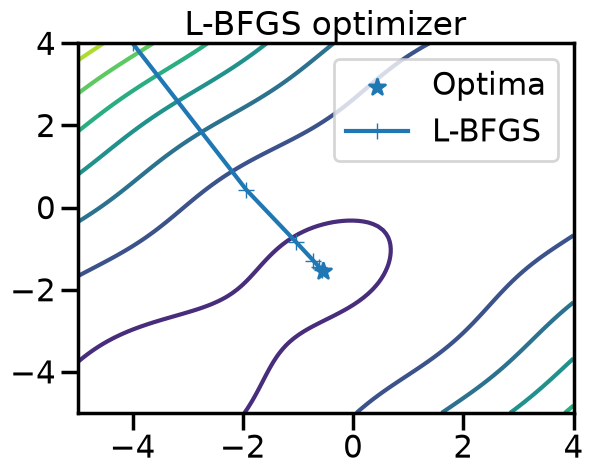

In [18]:
plt.figure()
plt.contour(x_plot,y_plot,f(X_plot))
plt.scatter([-0.54719],[-1.54719],marker='*',label="Optima")
plt.plot(steps[:,0],steps[:,1],marker='+',label = "L-BFGS")
plt.legend()
plt.title("L-BFGS optimizer")
plt.show()

## Demonstration of AD on Verlet Integration
This notebook demonstrates how to use Automatic Differentiation to determine the gradients of the initial conditions of a dynamical system (in this case a damped oscillator). To do this, we will define a numerical routine ([Verlet Integration](https://en.wikipedia.org/wiki/Verlet_integration)) and then use Automatic Differentiation to back propagate the gradient information from the output (Total system energy) to the initial conditions.

Below is a typical simulation script that is not current set up for automatic differentiation:

In [19]:

###############################################################################
N = 1000
t = np.linspace(0,10,N)
dt = t[1] - t[0]

###############################################################################
# functions
def integrate_original(F,x0,v0,gamma,dt=dt):
    N = len(F)   # number of steps = length of the force array
    ###########################################################################
    # arrays are allocated and filled with zeros
    Ef = 0
    x = np.zeros(N)
    v = np.zeros(N)
    E = np.zeros(N)
    
    ###########################################################################    
    # initial conditions
    x[0] = x0
    v[0] = v0
    
    ###########################################################################
    # Do the Verlet Integration
    fac1 = 1.0 - 0.5*gamma*dt
    fac2 = 1.0/(1.0 + 0.5*gamma*dt)
    
    for i in range(N-1):
        vn = fac1*fac2*v0 - fac2*dt*x0 + fac2*dt*F[i]
        xn = x0 + dt*vn
        Ef = 0.5*(x0**2 + ((v0 + vn)/2.0)**2)
        v0 = vn
        x0 = xn
        # For Plotting/Debug

        v[i + 1] = vn
        x[i + 1] = xn
        E[i] = Ef

    Ef = 0.5*(x0**2 + v0**2)
    
    E[-1] = Ef
    
    ###########################################################################
    # return solution
    return ( (x0,v0,Ef) , (x,v,E) )

Now note how we modify the code to include AD via PyTorch (see comments and references to `torch`):

In [20]:

###############################################################################
N = 1000
t = np.linspace(0,10,N)
dt = t[1] - t[0]

###############################################################################
# functions
def integrate(F,x0,v0,gamma,dt=dt):
    N = len(F)   # number of steps = length of the force array
    ###########################################################################
    # arrays are allocated and filled with zeros
    #x = torch.tensor([0.0],requires_grad=True)
    #v = torch.zeros(N)
    Ef = torch.tensor([0.0],requires_grad=True)
    x = np.zeros(N)
    v = np.zeros(N)
    E = np.zeros(N)
    
    ###########################################################################    
    # initial conditions
    with torch.no_grad():
        x[0] = x0
        v[0] = v0
    
    ###########################################################################
    # Do the Verlet Integration
    fac1 = 1.0 - 0.5*gamma*dt
    fac2 = 1.0/(1.0 + 0.5*gamma*dt)
    
    for i in range(N-1):
        vn = fac1*fac2*v0 - fac2*dt*x0 + fac2*dt*F[i]
        xn = x0 + dt*vn
        Ef = 0.5*(x0**2 + ((v0 + vn)/2.0)**2)
        v0 = vn
        x0 = xn
        # For Plotting/Debug
        with torch.no_grad():
            v[i + 1] = vn
            x[i + 1] = xn
            E[i] = Ef
    
    Ef = 0.5*(x0**2 + v0**2)
    with torch.no_grad():
        E[-1] = Ef
    
    ###########################################################################
    # return solution
    return ( (x0,v0,Ef) , (x,v,E) )

In [ ]:
###############################################################################
# Do the actual numerical integration
F = np.zeros(N)

x_initial = torch.tensor([1.0], requires_grad = True)
v_initial = torch.tensor([1.0], requires_grad = True)
#gamma = torch.tensor([0.05], requires_grad = True)
gamma = torch.tensor([.05], requires_grad = True)
((xf,vf,Ef),(x1,v1,E1)) = integrate(F,x_initial,v_initial,gamma)

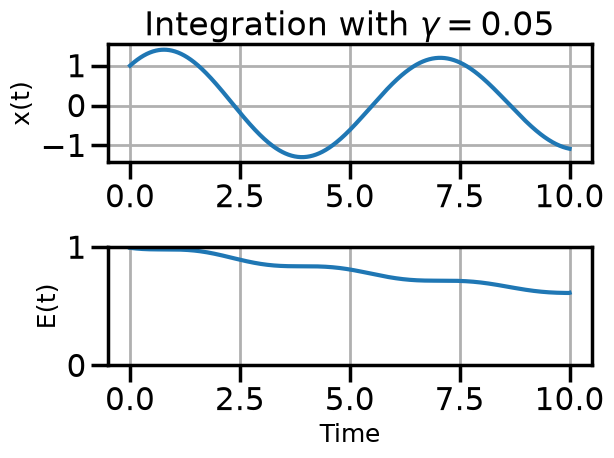

In [ ]:
def plot_solution(x1,E1,gamma):
    plt.rcParams["axes.grid"] = True
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 18
    plt.figure()
    plt.subplot(211)
    plt.title(f"Integration with $\gamma = {float(gamma):.2f}$")
    plt.plot(t,x1)
    plt.ylabel("x(t)")

    plt.subplot(212)
    plt.plot(t,E1,label=fr"$\gamma = {float(gamma):.2f}$")
    plt.ylim(0,1.0)
    plt.ylabel("E(t)")

    plt.xlabel("Time")
    plt.tight_layout()

plot_solution(x1,E1,gamma)


In [23]:
print(Ef)
Ef.backward(retain_graph=True)

tensor([0.6137], grad_fn=<MulBackward0>)


Now let's print the gradient of the system Energy with respect to some of the initial conditions:

In [24]:
print(gamma.grad)
print(v_initial.grad)
print(x_initial.grad)

tensor([-5.9562])
tensor([0.6026])
tensor([0.6248])


We can do the same for the final velocity. One thing to be careful about: PyTorch *accumulates* gradients into `.grad` rather than overwriting them, so a second `backward` call would add the new gradients to the ones we just printed. We zero them first (the optimizers below do the same thing with `optimizer.zero_grad()`).

In [25]:
# .grad accumulates: the gradients of Ef are still stored there, and a second
# backward call would add to them. Clear them first.
for p in (gamma, v_initial, x_initial):
    p.grad.zero_()

print(vf)
# Now we can call backward on the final velocity to get the gradients of the final velocity with respect to the initial conditions and gamma.
vf.backward()

tensor([-0.2245], grad_fn=<AddBackward0>)


In [26]:
print(gamma.grad)
print(v_initial.grad)
print(x_initial.grad)

tensor([1.2027])
tensor([-0.6463])
tensor([0.4218])


### Optimizing the Damping Coefficient via SGD and AD

First let's just get a visual intuition for how $\gamma$ affects the final energy:

In [27]:
num_gammas = 30
gamma_plot = np.logspace(-0.5,1.0,num_gammas)
Efs = np.zeros(num_gammas)
for i,g in enumerate(gamma_plot):
    ((xf,vf,Ef),(x1,v1,E1)) = integrate(F,x_initial,v_initial,g)
    Efs[i] = Ef

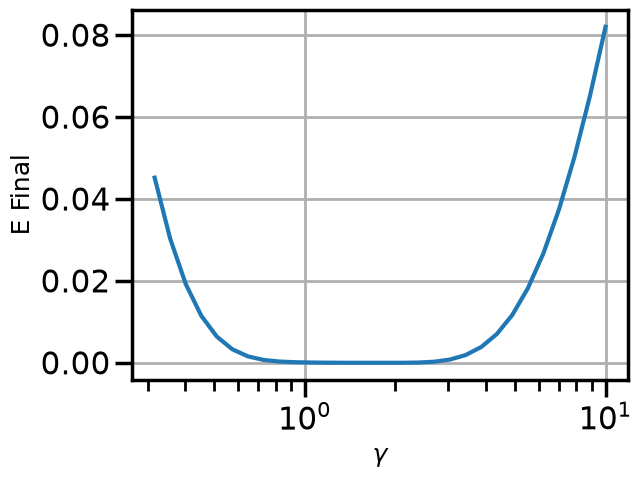

In [28]:
plt.figure()
plt.semilogx(gamma_plot,Efs)
plt.xlabel(r'$\gamma$')
plt.ylabel('E Final')
plt.show()

We can see that there is a pretty flat plateau from around $\gamma=1$ until around $\gamma=3$.

Now let's use our backward mode AD to actually optimize $\gamma$ directly by calling backward on the output of the final energy of the Verlet integration of the ODE:

In [29]:
# This part is just a helper library for plotting
def plot_optimization(initial_gamma, num_steps, optimizer, opt_kwargs={}):
    # Take an initial guess at the optimum:
    gamma = torch.tensor([initial_gamma], requires_grad=True)

    # Initialize the optimizer
    optimizer = optimizer([gamma], **opt_kwargs)

    steps = [ ] # Here is where we'll keep track of the steps
    # Take num_steps of the optimizer
    for i in range(num_steps):
        # This function runs an actual optimization step. We wrap it in closure so that optimizers
        # that take multiple function calls per step can do so -- e.g., LBFGS.
        def closure():
            # Get rid of the existing gradients on the tape
            optimizer.zero_grad()
            # Run the numerical integration -- this is the forward pass through the solver
            ((xf,vf,Ef),(x1,v1,E1)) = integrate(F,x_initial,v_initial,gamma) # x0 = 0.0, v0 = 1.0, gamma = 0.0
            # Compute the backward mode AD pass
            Ef.backward()
            return Ef
        # Now ask the optimizer to take a step
        optimizer.step(closure)
        
        # The below part is just for printing/plotting. We call torch.no_grad() here to signify that
        # we do not need to track this as part of the gradient operations. That is, these parts will not
        # be added to the computational graph or used for backward mode AD.
        with torch.no_grad():
            #print(gamma)
            # Run again just to plot the solution for this gamma
            ((xf,vf,Ef),(x1,v1,E1)) = integrate(F,x_initial,v_initial,gamma)
            #print(Ef)
            if num_steps>10 and i%3==0:
                plot_solution(x1,E1,gamma)
            # Add it to steps so that we can see/plot it later.
            steps.append(np.array(gamma.detach().numpy()))
            
    steps = np.array(steps)
    return steps

#### Adam Example

Here, we use Automatic Differentation through the integrator to optimize the dynamical system using Adam.

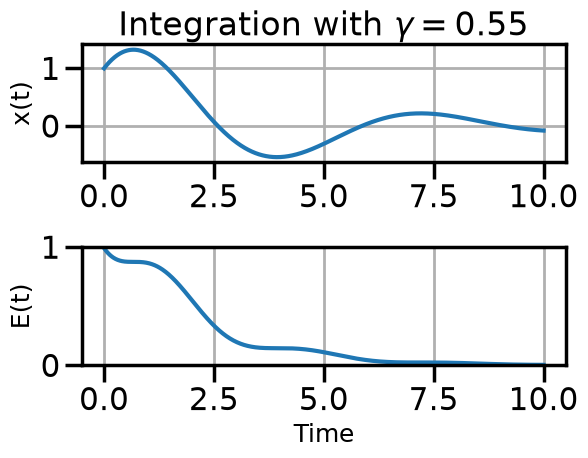

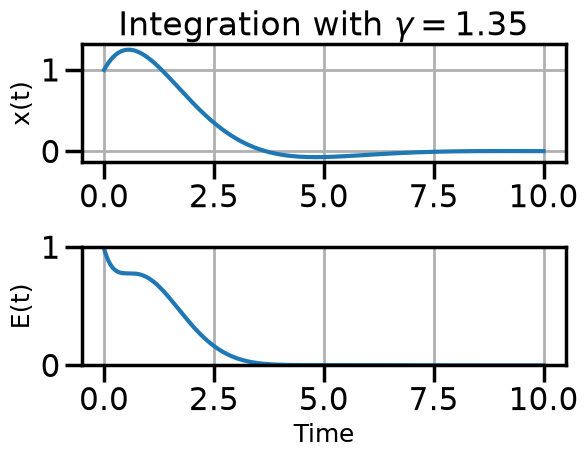

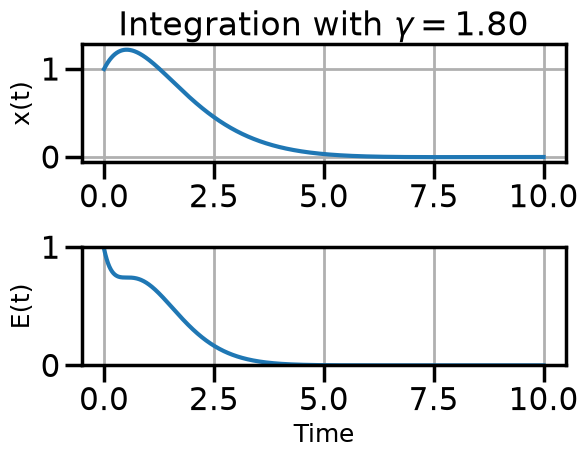

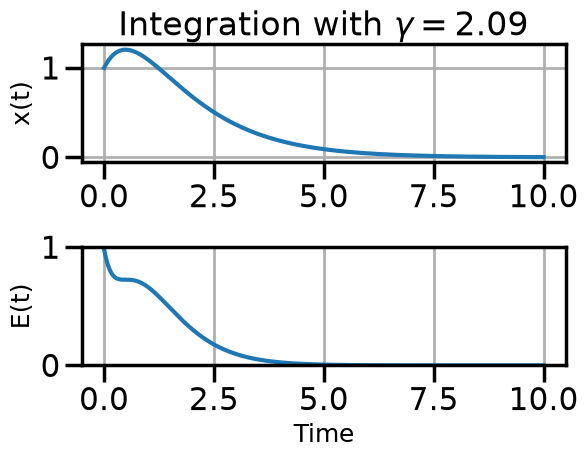

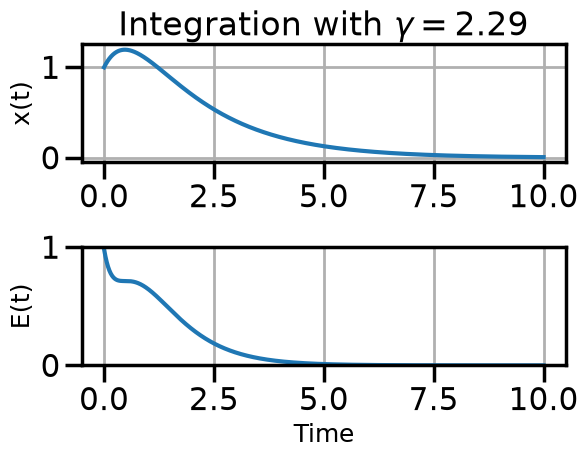

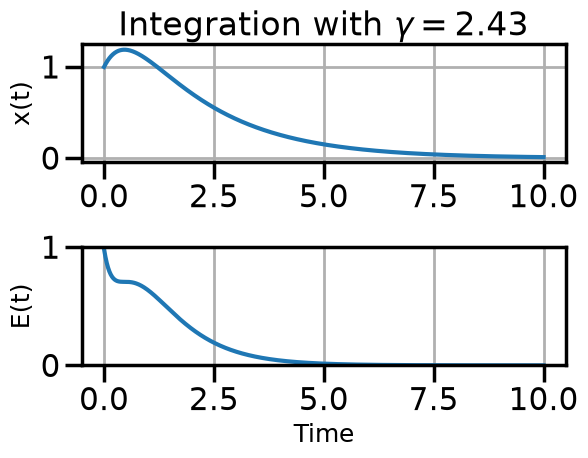

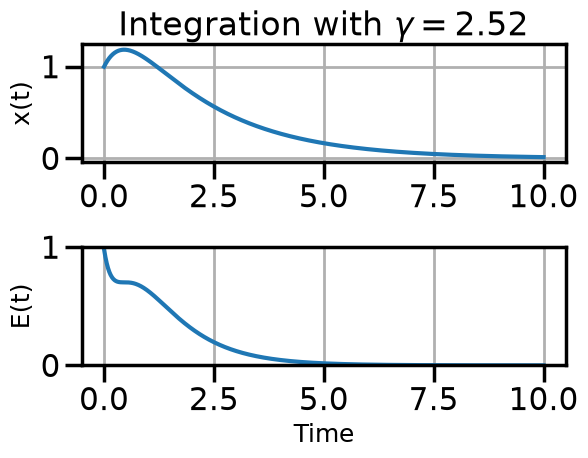

In [30]:
steps_Adam = plot_optimization(initial_gamma=0.05, 
                               num_steps=20,
                               optimizer=torch.optim.AdamW,
                               opt_kwargs={'lr':0.5})

#### SGD Example

Here is the same example, but using SGD as the optimizer:

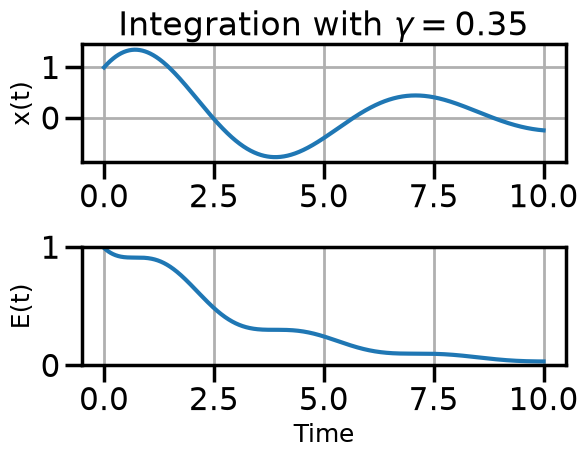

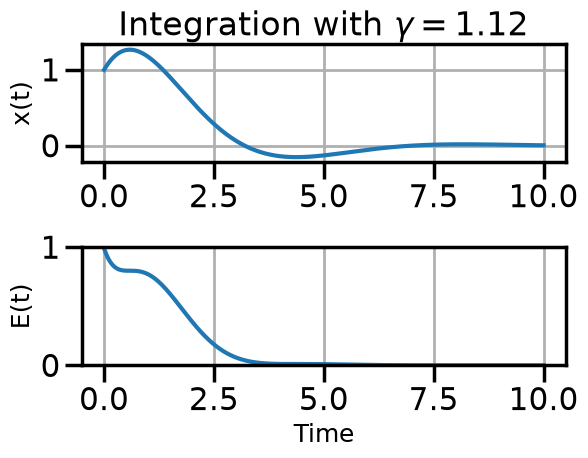

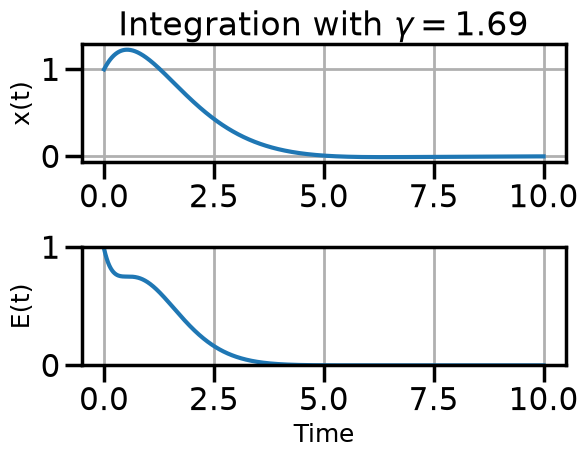

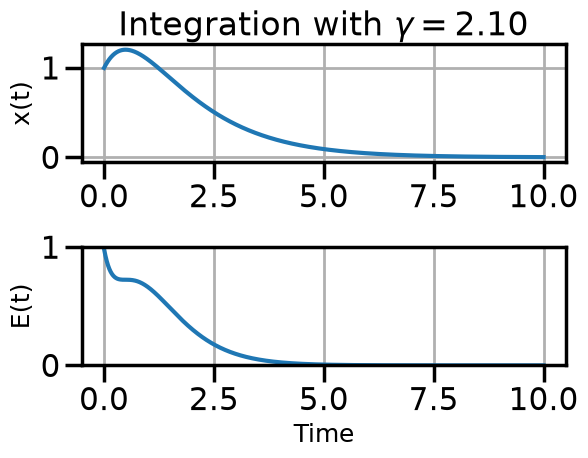

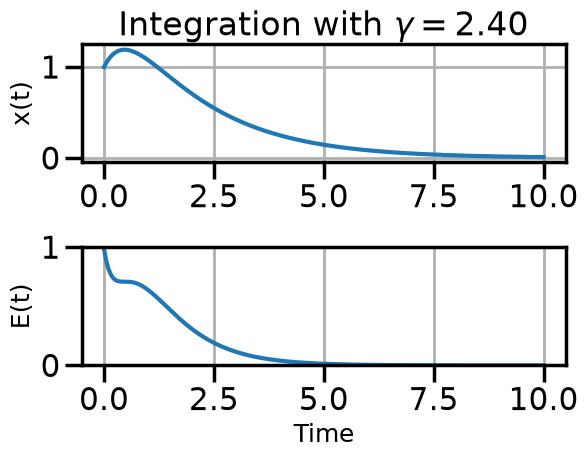

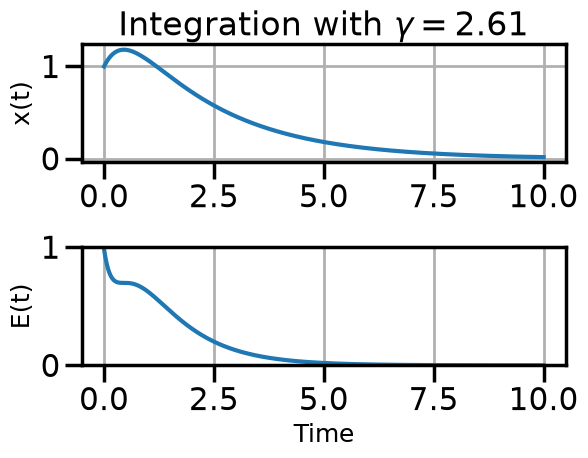

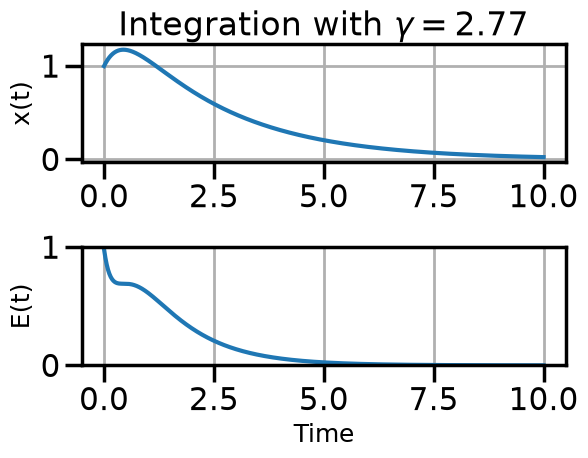

In [31]:
steps_SGD = plot_optimization(initial_gamma=0.05, 
                               num_steps=20,
                               optimizer=torch.optim.SGD,
                               opt_kwargs={'lr':0.05,'momentum':0.9})

#### L-BFGS Example
Lastly, we can also attempt this with L-BFGS. (Warning: Per-run solves of LBFGS take a while, so don't set num_steps too high here)

In [32]:
steps_LBFGS = plot_optimization(initial_gamma=0.05,
                                num_steps=5,
                                optimizer=torch.optim.LBFGS,
                                opt_kwargs={'lr':0.3})

### Compare the steps taken

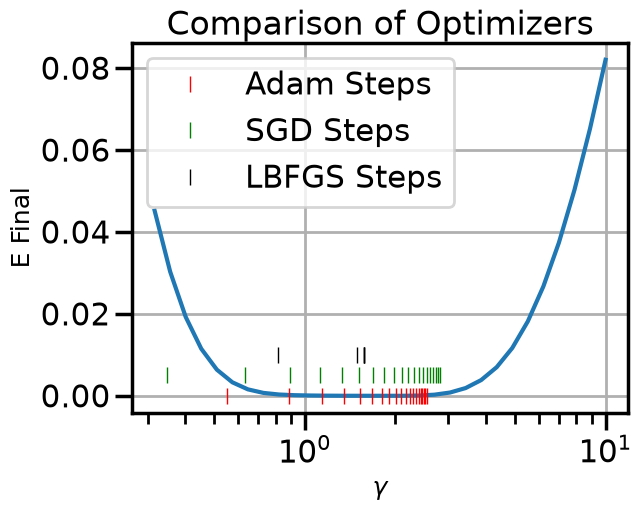

In [33]:
plt.figure()
plt.semilogx(gamma_plot,Efs)
steps_Adam = steps_Adam.flatten()
plt.plot(steps_Adam,[0.0]*len(steps_Adam),'|', color = 'r', label = 'Adam Steps')
plt.plot(steps_SGD,[0.005]*len(steps_SGD),'|', color = 'g', label = 'SGD Steps')
plt.plot(steps_LBFGS,[0.01]*len(steps_LBFGS),'|', color = 'k', label = 'LBFGS Steps')
plt.xlabel(r'$\gamma$')
plt.ylabel('E Final')
plt.title("Comparison of Optimizers")
plt.legend()
plt.show()

## Exercises

The exercises below reuse the McCormick function `mccormick` and the Verlet integrator `integrate` from this chapter, so run the chapter's cells first. The first two are pencil-and-paper exercises with a short autograd check at the end; the last one is meant as a longer take-home task.

::: {.callout-note appearance="simple" icon=false}
### Exercise 1 (~8 min): Forward mode through an unrolled solver
Kepler's equation $M = E - e \sin E$ relates the mean anomaly $M$ of an orbit to its eccentric anomaly $E$ for an eccentricity $e$. It has no closed-form solution for $E$, so it is solved by iterating $E_{k+1} = M + e \sin E_k$ from $E_0 = M$. Suppose a program runs exactly two iterations and returns two outputs, the correction $f = E_2 - M$ and the normalized orbital radius $r = 1 - e \cos E_2$. Its computational graph, in the notation of the chapter, is

| Node | Definition | Node | Definition |
|---|---|---|---|
| $v_1$ | $M$ | $v_7$ | $v_2 \cdot v_6$ |
| $v_2$ | $e$ | $v_8$ | $v_1 + v_7 \;(= E_2)$ |
| $v_3$ | $\sin v_1$ | $f$ | $v_8 - v_1$ |
| $v_4$ | $v_2 \cdot v_3$ | $v_9$ | $\cos v_8$ |
| $v_5$ | $v_1 + v_4 \;(= E_1)$ | $v_{10}$ | $v_2 \cdot v_9$ |
| $v_6$ | $\sin v_5$ | $r$ | $1 - v_{10}$ |

Evaluate everything at $(M, e) = (0, \tfrac{1}{2})$.

- (a) Fill in the forward pass (the value of every node) and then the forward-mode tangent table for the seed $(\dot{M}, \dot{e}) = (1, 0)$, in the style of the chapter's Case A. Which two derivatives have you obtained, and why does one of them come out as zero?
- (b) Check both outputs' derivatives with respect to both inputs using `torch.autograd`. How many forward-mode passes would you have needed for the full table, and how many `backward` calls did you need? Why do the counts differ?
- (c) If the program ran twenty iterations instead of two, what would change in your table and what would not? Why does this matter for the simulations at the end of the chapter?
:::

In [34]:
# You can use this code cell for this exercise, if you like.

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 2 (~10 min): Reverse mode on a pump model
A deliberately simplified model of a centrifugal pump takes the flow rate $Q$, the impeller speed $n$ and the fluid density $\rho$ and returns the hydraulic power $P_h$ and the efficiency $\eta$ through the head $H$:

$$
H = \frac{n^2}{Q}, \qquad P_h = \rho\, Q\, H, \qquad \eta = \frac{Q}{\sqrt{H}} .
$$

Its computational graph, in the notation of the chapter, is

| Node | Definition |
|---|---|
| $v_1$ | $Q$ |
| $v_2$ | $n$ |
| $v_3$ | $\rho$ |
| $v_4$ | $v_2 \cdot v_2$ |
| $v_5$ | $v_4 / v_1 \;(= H)$ |
| $v_6$ | $\sqrt{v_5}$ |
| $v_7$ | $v_3 \cdot v_1$ |
| $P_h$ | $v_7 \cdot v_5$ |
| $\eta$ | $v_1 / v_6$ |

Evaluate everything at $(Q, n, \rho) = (4, 4, 3)$.

- (a) Sketch the graph and run the forward pass. Which node is used by both outputs, and which input is used more than once?
- (b) Run a reverse-mode pass seeded at $P_h$ (that is, $\bar{P}_h = 1$, $\bar{\eta} = 0$) and a second one seeded at $\eta$, in the style of the chapter's adjoint table, and assemble the $2 \times 3$ Jacobian $\partial (P_h, \eta) / \partial (Q, n, \rho)$. Where in the tables do contributions from different paths have to be added, and why?
- (c) $\partial P_h / \partial Q$ comes out as exactly zero even though $Q$ feeds the graph in two places. What cancels, and what does it say about the model?
- (d) For this pump, which mode of automatic differentiation gives the full Jacobian with fewer passes, and how many? Now consider two other models: one maps 2 design parameters to a 200-sample pressure trace, the other maps 200 blade-surface coordinates to one efficiency number. Which mode would you use for each, how many passes does it take, and what does reverse mode cost that forward mode does not?
- (e) Check your Jacobian with `torch.autograd`. Why do you need to be careful with `.grad` between the two `backward` calls?
:::

In [35]:
# You can use this code cell for this exercise, if you like.

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 3 (~8 min): Reading the optimizer paths
Look again at the two McCormick paths the chapter produced from the start $(-4, 4)$: AdamW with `lr=1` for 50 steps, and L-BFGS with `lr=0.05` for 5 calls of `step`.

- (a) Use the chapter's description of each optimizer to explain the shape of its path. Why does the AdamW path run past the valley and loop around before settling, and why does the L-BFGS path run almost straight to the minimum?
- (b) The cell below reruns both optimizers, with the same settings, from the start $(3, 3)$ and plots the paths on a wider window. Where does each optimizer end up, and why does each end where it does?
- (c) The chapter marks $(-0.547, -1.547)$ as the optimum. What do these two runs tell you about that claim, and what should you check before trusting where any optimizer stops?
:::

Run the cell below to produce the figure for Exercise 3 (b).

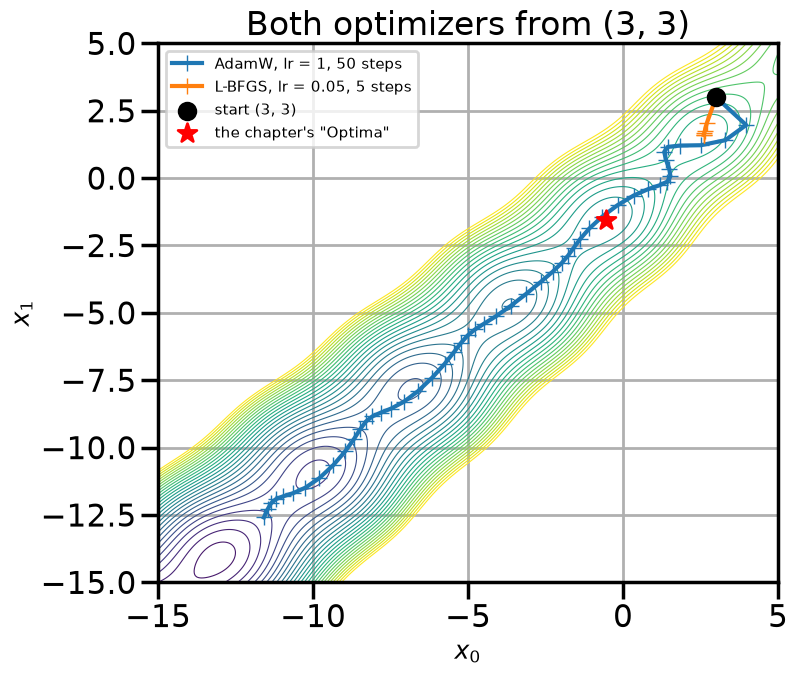

AdamW ends at (-11.59, -12.59) with f = -11.27
L-BFGS ends at (2.60, 1.60) with f = 1.23


In [36]:
#| echo: false
second_start = [3.0, 3.0]


def run_optimizer_path(start, make_optimizer, num_steps):
    """Run an optimizer on the McCormick function from `start` and return every iterate."""
    x = torch.tensor(start, requires_grad=True)
    optimizer = make_optimizer([x])
    path = [x.detach().numpy().copy()]
    for i in range(num_steps):
        def closure():
            optimizer.zero_grad()
            y = mccormick(x)
            y.backward()
            return y
        optimizer.step(closure)
        path.append(x.detach().numpy().copy())
    return np.array(path)


path_adam = run_optimizer_path(second_start, lambda p: torch.optim.AdamW(p, lr=1), 50)
path_lbfgs = run_optimizer_path(second_start, lambda p: torch.optim.LBFGS(p, lr=0.05), 5)

X_wide = torch.meshgrid(torch.linspace(-15, 5, 400), torch.linspace(-15, 5, 400), indexing='ij')
plt.figure(figsize=(8, 7))
plt.contour(X_wide[0], X_wide[1], mccormick(X_wide), levels=np.arange(-16, 14, 1.0), linewidths=0.8)
plt.plot(path_adam[:, 0], path_adam[:, 1], marker='+', label='AdamW, lr = 1, 50 steps')
plt.plot(path_lbfgs[:, 0], path_lbfgs[:, 1], marker='+', label='L-BFGS, lr = 0.05, 5 steps')
plt.scatter([second_start[0]], [second_start[1]], marker='o', color='k', zorder=5, label='start (3, 3)')
plt.scatter([-0.54719], [-1.54719], marker='*', s=200, color='r', zorder=5, label='the chapter\'s "Optima"')
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.legend(loc='upper left', fontsize=11)
plt.title('Both optimizers from (3, 3)')
plt.show()
print(f"AdamW ends at ({path_adam[-1][0]:.2f}, {path_adam[-1][1]:.2f}) with f = {mccormick(torch.tensor(path_adam[-1])).item():.2f}")
print(f"L-BFGS ends at ({path_lbfgs[-1][0]:.2f}, {path_lbfgs[-1][1]:.2f}) with f = {mccormick(torch.tensor(path_lbfgs[-1])).item():.2f}")

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 4 (~8 min): Vanishing and exploding gradients
The logistic map

$$
x_{k+1} = r\, x_k (1 - x_k)
$$

is a one-line model of a quantity that grows in proportion to itself and saturates at 1, such as a population or the market share of a product. It has the same structure as the time-stepping loop of a simulator: the same function is applied to its own output again and again. The cell below runs 40 steps from $x_0 = 0.2$ for $r = 2.5$ and for $r = 3.9$, calls `backward` on $x_{40}$, and plots the iterates and the adjoints $\bar{x}_k = \partial x_{40} / \partial x_k$ that reverse mode passes back through the loop (`retain_grad` keeps them after the backward pass).

- (a) Use the chain rule to write $\bar{x}_k$ as a product of local derivatives, one per step. For $r = 2.5$ the iterates settle at a fixed point. Find the fixed point and the local derivative there by hand, and predict by what factor $|\bar{x}_k|$ changes from one step to the next. Check your prediction against the plot and the printed values. Why is the curve a straight line?
- (b) For $r = 3.9$ the iterates stay between 0 and 1 at every step, yet $|\partial x_{40} / \partial x_0|$ is about $10^{9}$. How can both be true? What does this tell you about judging whether a loop's gradient is usable from its forward values?
- (c) Suppose $x_0$ were a parameter that you fit by gradient descent on a loss that depends on $x_{40}$. What happens to the gradient step for each value of $r$, and why does a longer loop make both cases worse? Many Neural Network models apply the same small function to their own output at every step of a sequence, such as in Recurrent neural networks, which are used for time series. What would you expect of their gradients, and how does it relate to the behavior you saw with the logistic map?
:::

r = 2.5: x_40 = 0.6000, dx_40/dx_0 = 2.73e-12, adjoints at k = 40, 39, 38, 37: 1, -0.5, 0.25, -0.125
r = 3.9: x_40 = 0.8912, dx_40/dx_0 = -6.37e+09, adjoints at k = 40, 39, 38, 37: 1, 1.143, -3.559, 3.87


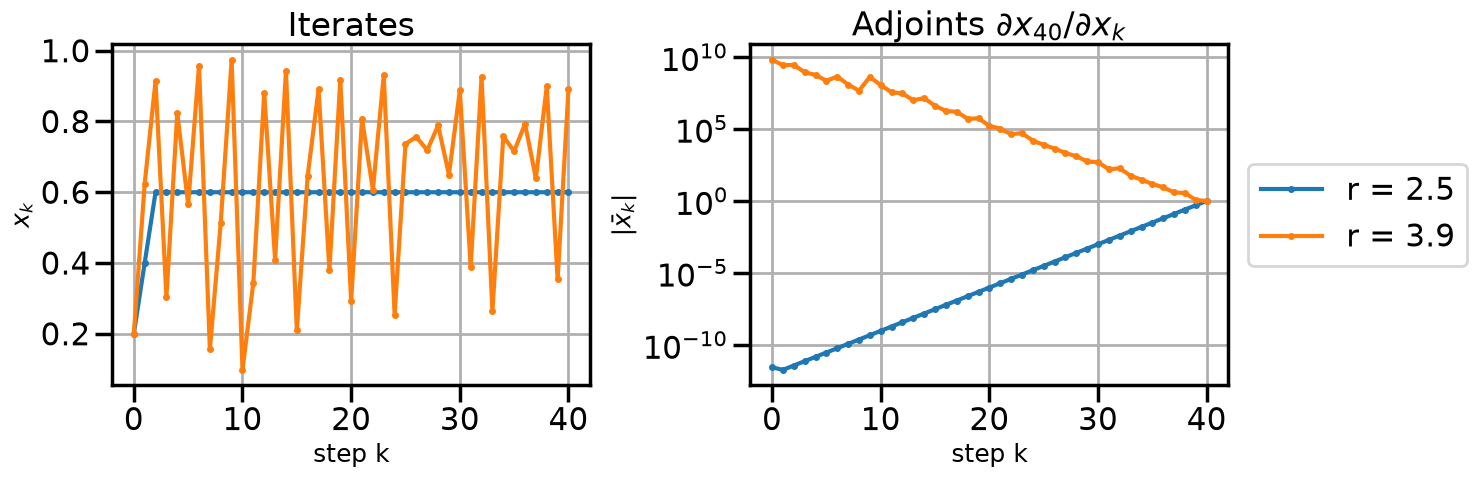

In [37]:
def logistic_adjoints(r, x0=0.2, n_steps=40):
    """Run n_steps of the logistic map from x0; return the iterates x_k and the adjoints d x_N / d x_k."""
    xs = [torch.tensor(x0, dtype=torch.float64, requires_grad=True)]
    for k in range(n_steps):
        x_next = r * xs[-1] * (1 - xs[-1])
        x_next.retain_grad()               # keep this node's adjoint after the backward pass
        xs.append(x_next)
    xs[-1].backward()
    iterates = np.array([x.item() for x in xs])
    adjoints = np.array([x.grad.item() for x in xs])
    return iterates, adjoints


rates = [2.5, 3.9]
fig, (ax_x, ax_adj) = plt.subplots(1, 2, figsize=(15, 5))
for r in rates:
    iterates, adjoints = logistic_adjoints(r)
    ax_x.plot(iterates, 'o-', ms=4, label=f"r = {r}")
    ax_adj.semilogy(np.abs(adjoints), 'o-', ms=4, label=f"r = {r}")
    print(f"r = {r}: x_40 = {iterates[-1]:.4f}, dx_40/dx_0 = {adjoints[0]:.2e}, "
          f"adjoints at k = 40, 39, 38, 37: " + ", ".join(f"{a:.4g}" for a in adjoints[:-5:-1]))
ax_x.set_xlabel("step k")
ax_x.set_ylabel("$x_k$")
ax_x.set_title("Iterates")
ax_adj.set_xlabel("step k")
ax_adj.set_ylabel(r"$|\bar{x}_k|$")
ax_adj.set_title(r"Adjoints $\partial x_{40} / \partial x_k$")
ax_adj.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))   # outside the axes, so it covers no data
plt.tight_layout()
plt.show()

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 5 (~10 min): A heat exchanger formula with a hidden trap
The heat duty of a heat exchanger with overall heat transfer coefficient $U$ and area $A$ is $\dot{Q} = U A\, \Delta T_\mathrm{lm}$, where the log-mean temperature difference

$$
\Delta T_\mathrm{lm} = \frac{\Delta T_1 - \Delta T_2}{\ln(\Delta T_1 / \Delta T_2)}
$$

combines the temperature differences $\Delta T_1$ and $\Delta T_2$ between the two fluids at the two ends of the exchanger. When $\Delta T_1 = \Delta T_2$, which happens in a counterflow exchanger whose two streams have equal heat capacity rates, the formula reads $0/0$, but its limit is simply $\Delta T_1$. The cell below writes the formula in PyTorch and evaluates it and its autograd derivative $\partial \Delta T_\mathrm{lm} / \partial \Delta T_1$ at $\Delta T_2 = 50$ K and $\Delta T_1 = 50\,\mathrm{K} + \delta$, for $\delta$ from 10 K down to $10^{-4}$ K, once in `float32` (PyTorch's default) and once in `float64`.

- (a) Before running the cell, what value should $\partial \Delta T_\mathrm{lm} / \partial \Delta T_1$ approach as $\delta \to 0$? Why?
- (b) Run the cell. Down to which $\delta$ is the `float32` value accurate, and down to which $\delta$ is the `float32` derivative accurate? Why does the derivative fail at a much larger $\delta$ than the value? What happens at $\delta = 0$, and why?
- (c) A design optimizer that adjusts the flow rates by gradient descent may approach balanced flow. What gradients would it receive there? Change `lmtd` so that its derivative can be trusted for every $\delta$, including $\delta = 0$, and explain why your change works. Why is switching to `float64` not enough?
:::

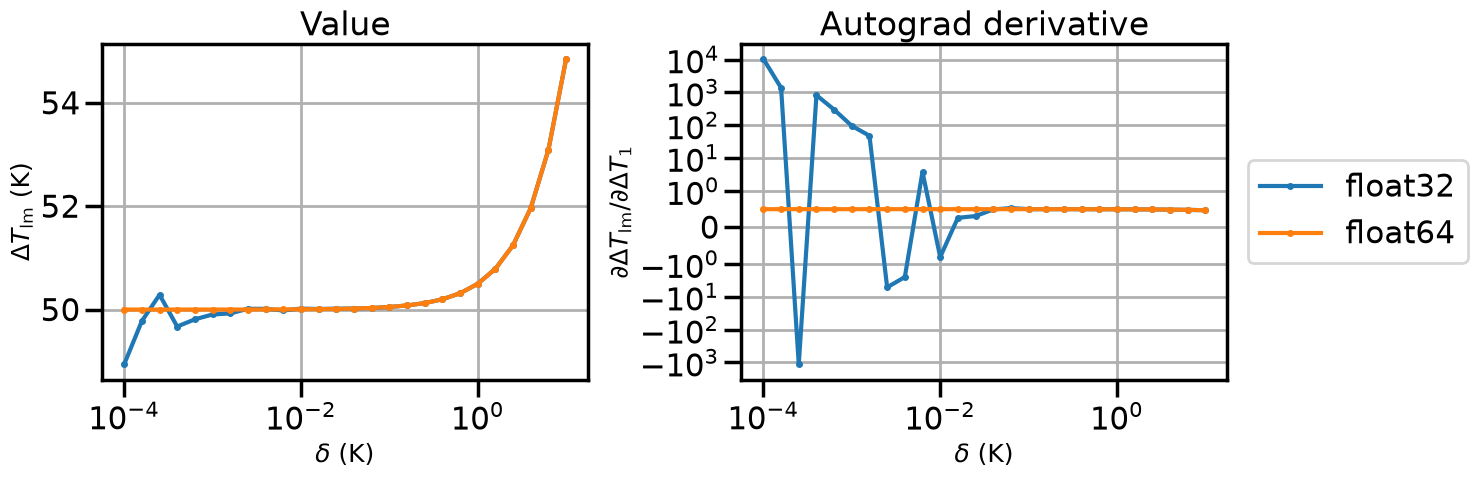

delta = 1 K: float32: value 50.4984, derivative 0.4967; float64: value 50.4983, derivative 0.4967
delta = 0.01 K: float32: value 50.0181, derivative -0.8125; float64: value 50.0050, derivative 0.5
delta = 0.0001 K: float32: value 48.9412, derivative 1.045e+04; float64: value 50.0001, derivative 0.5
delta = 0 K: float32: value nan, derivative nan; float64: value nan, derivative nan


In [38]:
def lmtd(dT1, dT2):
    """Log-mean temperature difference for end temperature differences dT1 and dT2."""
    return (dT1 - dT2) / torch.log(dT1 / dT2)


def lmtd_and_slope(delta, dtype):
    """lmtd and its autograd derivative with respect to dT1, at dT1 = 50 + delta and dT2 = 50 (kelvin)."""
    dT1 = torch.tensor(50.0 + delta, dtype=dtype, requires_grad=True)
    dT2 = torch.tensor(50.0, dtype=dtype)
    value = lmtd(dT1, dT2)
    value.backward()
    return value.item(), dT1.grad.item()


deltas = np.logspace(1, -4, 26)        # K, from 10 down to 1e-4
fig, (ax_value, ax_slope) = plt.subplots(1, 2, figsize=(15, 5))
for dtype in (torch.float32, torch.float64):
    values, slopes = zip(*[lmtd_and_slope(delta, dtype) for delta in deltas])
    name = str(dtype).replace("torch.", "")
    ax_value.semilogx(deltas, values, 'o-', ms=4, label=name)
    ax_slope.semilogx(deltas, slopes, 'o-', ms=4, label=name)
ax_slope.set_yscale('symlog', linthresh=1)   # linear between -1 and 1, logarithmic outside
ax_value.set_xlabel(r"$\delta$ (K)")
ax_value.set_ylabel(r"$\Delta T_\mathrm{lm}$ (K)")
ax_value.set_title("Value")
ax_slope.set_xlabel(r"$\delta$ (K)")
ax_slope.set_ylabel(r"$\partial \Delta T_\mathrm{lm} / \partial \Delta T_1$")
ax_slope.set_title("Autograd derivative")
ax_slope.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

for delta in [1.0, 1e-2, 1e-4, 0.0]:
    print(f"delta = {delta:g} K: " + "; ".join(
        f"{str(dtype).replace('torch.', '')}: value {v:.4f}, derivative {s:.4g}"
        for dtype in (torch.float32, torch.float64) for v, s in [lmtd_and_slope(delta, dtype)]))

In [39]:
# You can use this code cell for this exercise, if you like.

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 6 (~15 min): Fit damping and stiffness together (take-home)
The chapter fitted the damping $\gamma$ of the oscillator by gradient descent through the simulator, with the stiffness fixed at one. Now suppose both the damping and stiffness are unknown. The cell below produces a measured displacement record `x_measured` of a unit-mass oscillator with unknown damping $\gamma$ and stiffness $k$, released from $x_0 = 1$ with $v_0 = 1$, sampled at the `N_record` times in `t_record` with some measurement noise.

- (a) Extend the chapter's integrator so that the restoring force is $-k\,x$ with $k$ a parameter, and so that it returns the positions as a tensor autograd can see (the chapter's version only stores them as NumPy arrays). Define the loss as the mean squared difference between the simulated and measured positions. Implement this however you like.
- (b) Fit $\gamma$ and $k$ jointly from `x_measured`, once with Adam and once with L-BFGS, starting both from $\gamma = 0.1$, $k = 1$. Report the two parameter estimates and the final loss of each. Which optimizer gets there, which gets close, and why?
- (c) Fitting $\gamma$ alone with $k$ known worked with any of the chapter's optimizers. Why is the joint fit harder? What feature of the trajectory pins down $k$, what feature pins down $\gamma$, and how can a wrong $k$ be partly compensated by a wrong $\gamma$? A plot of the loss over a grid of $(\gamma, k)$ pairs will help you argue.
:::

Run the cell below to produce the measured record for Exercise 6.

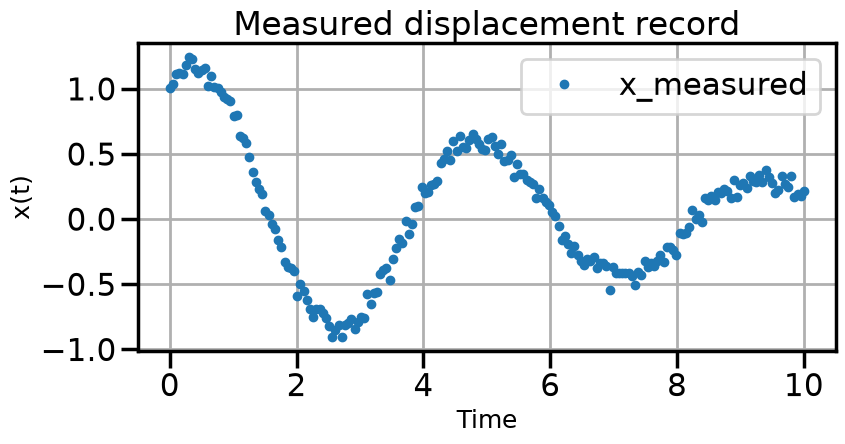

In [40]:
#| echo: false
# A noisy displacement record of a damped oscillator with unknown damping and stiffness.
N_record = 200
t_record = np.linspace(0, 10, N_record)
dt_record = t_record[1] - t_record[0]


def _simulate_record(gamma_true, k_true):
    x0, v0 = 1.0, 1.0
    fac1 = 1.0 - 0.5*gamma_true*dt_record
    fac2 = 1.0/(1.0 + 0.5*gamma_true*dt_record)
    x = np.zeros(N_record)
    x[0] = x0
    for i in range(N_record - 1):
        v0 = fac1*fac2*v0 - fac2*dt_record*k_true*x0
        x0 = x0 + dt_record*v0
        x[i + 1] = x0
    return x


_record_rng = np.random.default_rng(0)
x_measured = _simulate_record(0.3, 2.0) + 0.05*_record_rng.normal(size=N_record)

plt.figure(figsize=(9, 4))
plt.plot(t_record, x_measured, '.', label='x_measured')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.legend()
plt.title('Measured displacement record')
plt.show()

In [41]:
# You can use this code cell for this exercise, if you like.